### Run the StatsBombDataLoad file first to get your data set

### Packages

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Plotting / Formatting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.font_manager import FontManager
%matplotlib inline
import matplotlib as mpl
from highlight_text import HighlightText, ax_text, fig_text

# Mplsoccer for pitches
from mplsoccer import Pitch, VerticalPitch, FontManager

# Statsbomb to load data
import statsbombpy as sb
import json
from pandas import json_normalize

# Heatmaps filter
from scipy.ndimage import gaussian_filter

# Ignore warnings
import warnings
from pandas.core.common import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

### Import dataset after running the StatsBombDataLoad file

### Then fIlter through df by event and calc expected threat of each pass

In [4]:
df = pd.read_csv('Data/events.csv')

# filter by action and player; since we are plotting xT, we want to pull only passes (can also do carries)
passes = df.loc[df['type'] == 'Pass']
passes = passes.loc[passes['play_pattern'] == 'Regular Play']
passes = passes.loc[passes['player'] == 'Lionel Andrés Messi Cuccittini']

# create a copy of the df to avoid copy errors
passes = passes.copy()
# change the datatype of the location and end location columns to strings; will allow us to split columns by x & y coordinates
passes['location'] = passes['location'].astype('str')
passes['pass_end_location'] = passes['pass_end_location'].astype('str')    
    
# this function takes a StatsBomb df and then splits location columns into separate x, y, endX and endY columns
def splitCols(a):
    a['x'] = a['location'].str.split(',').str[0].str.strip('[').astype('float')
    a['y'] = a['location'].str.split(',').str[1].str.strip(']').astype('float')
    a['endX'] = a['pass_end_location'].str.split(',').str[0].str.strip('[').astype('float')
    a['endY'] = a['pass_end_location'].str.split(',').str[1].str.strip(']').astype('float')
    
splitCols(passes)

# once we have separate x and y coordinates for start and end locations we can calc expected threat
def xThreat(a):
    # import xT grid; Grid by Twelve Football saved in "xT Grid" Folder
    xT = pd.read_csv('xT Grid/xT_Grid.csv')

    # convert xT df into an np array
    xT = np.array(xT)

    # calculate number of rows and colums
    xT_rows, xT_cols = xT.shape

    # create bins to determine which section of the action started and ended
    a['x1_bin'] = pd.cut(a['x'], bins = xT_cols, labels=False)
    a['y1_bin'] = pd.cut(a['y'], bins = xT_rows, labels=False)
    a['x2_bin'] = pd.cut(a['endX'], bins = xT_cols, labels=False)
    a['y2_bin'] = pd.cut(a['endY'], bins = xT_rows, labels=False)

    # match xT value from grid to its corresponding bin by creating 2 new cols
    a['start_zone_value'] = a[['x1_bin', 'y1_bin']].apply(lambda x: xT[x[1]][x[0]], axis=1)
    a['end_zone_value'] = a[['x2_bin', 'y2_bin']].apply(lambda x: xT[x[1]][x[0]], axis=1)

    # calc xT by subtractinc start minus end zone probability
    a['xT'] = a['end_zone_value'] - a['start_zone_value']

xThreat(passes)

# can comment out if you want; I prefer not to include 04/05 season given limited amount of events
passes = passes[passes['season'] != '2004/2005']

# more for checking purposes but the code below creates a new df with number of passes in each season
# can verify if data was pulled correctly with Fbref
event_counts = passes.groupby('season').agg({'season': ['count']})
event_counts.columns = ['passes_made']
event_counts.reset_index(inplace=True)

# create another df that aggregates the total xT accumulated each season
xt_ssn = passes.groupby('season').agg({'xT': ['sum']})
xt_ssn.columns = ['sum_xT']
xt_ssn.reset_index(inplace=True)

NumExpr defaulting to 4 threads.


### Run the last block below to get your final output

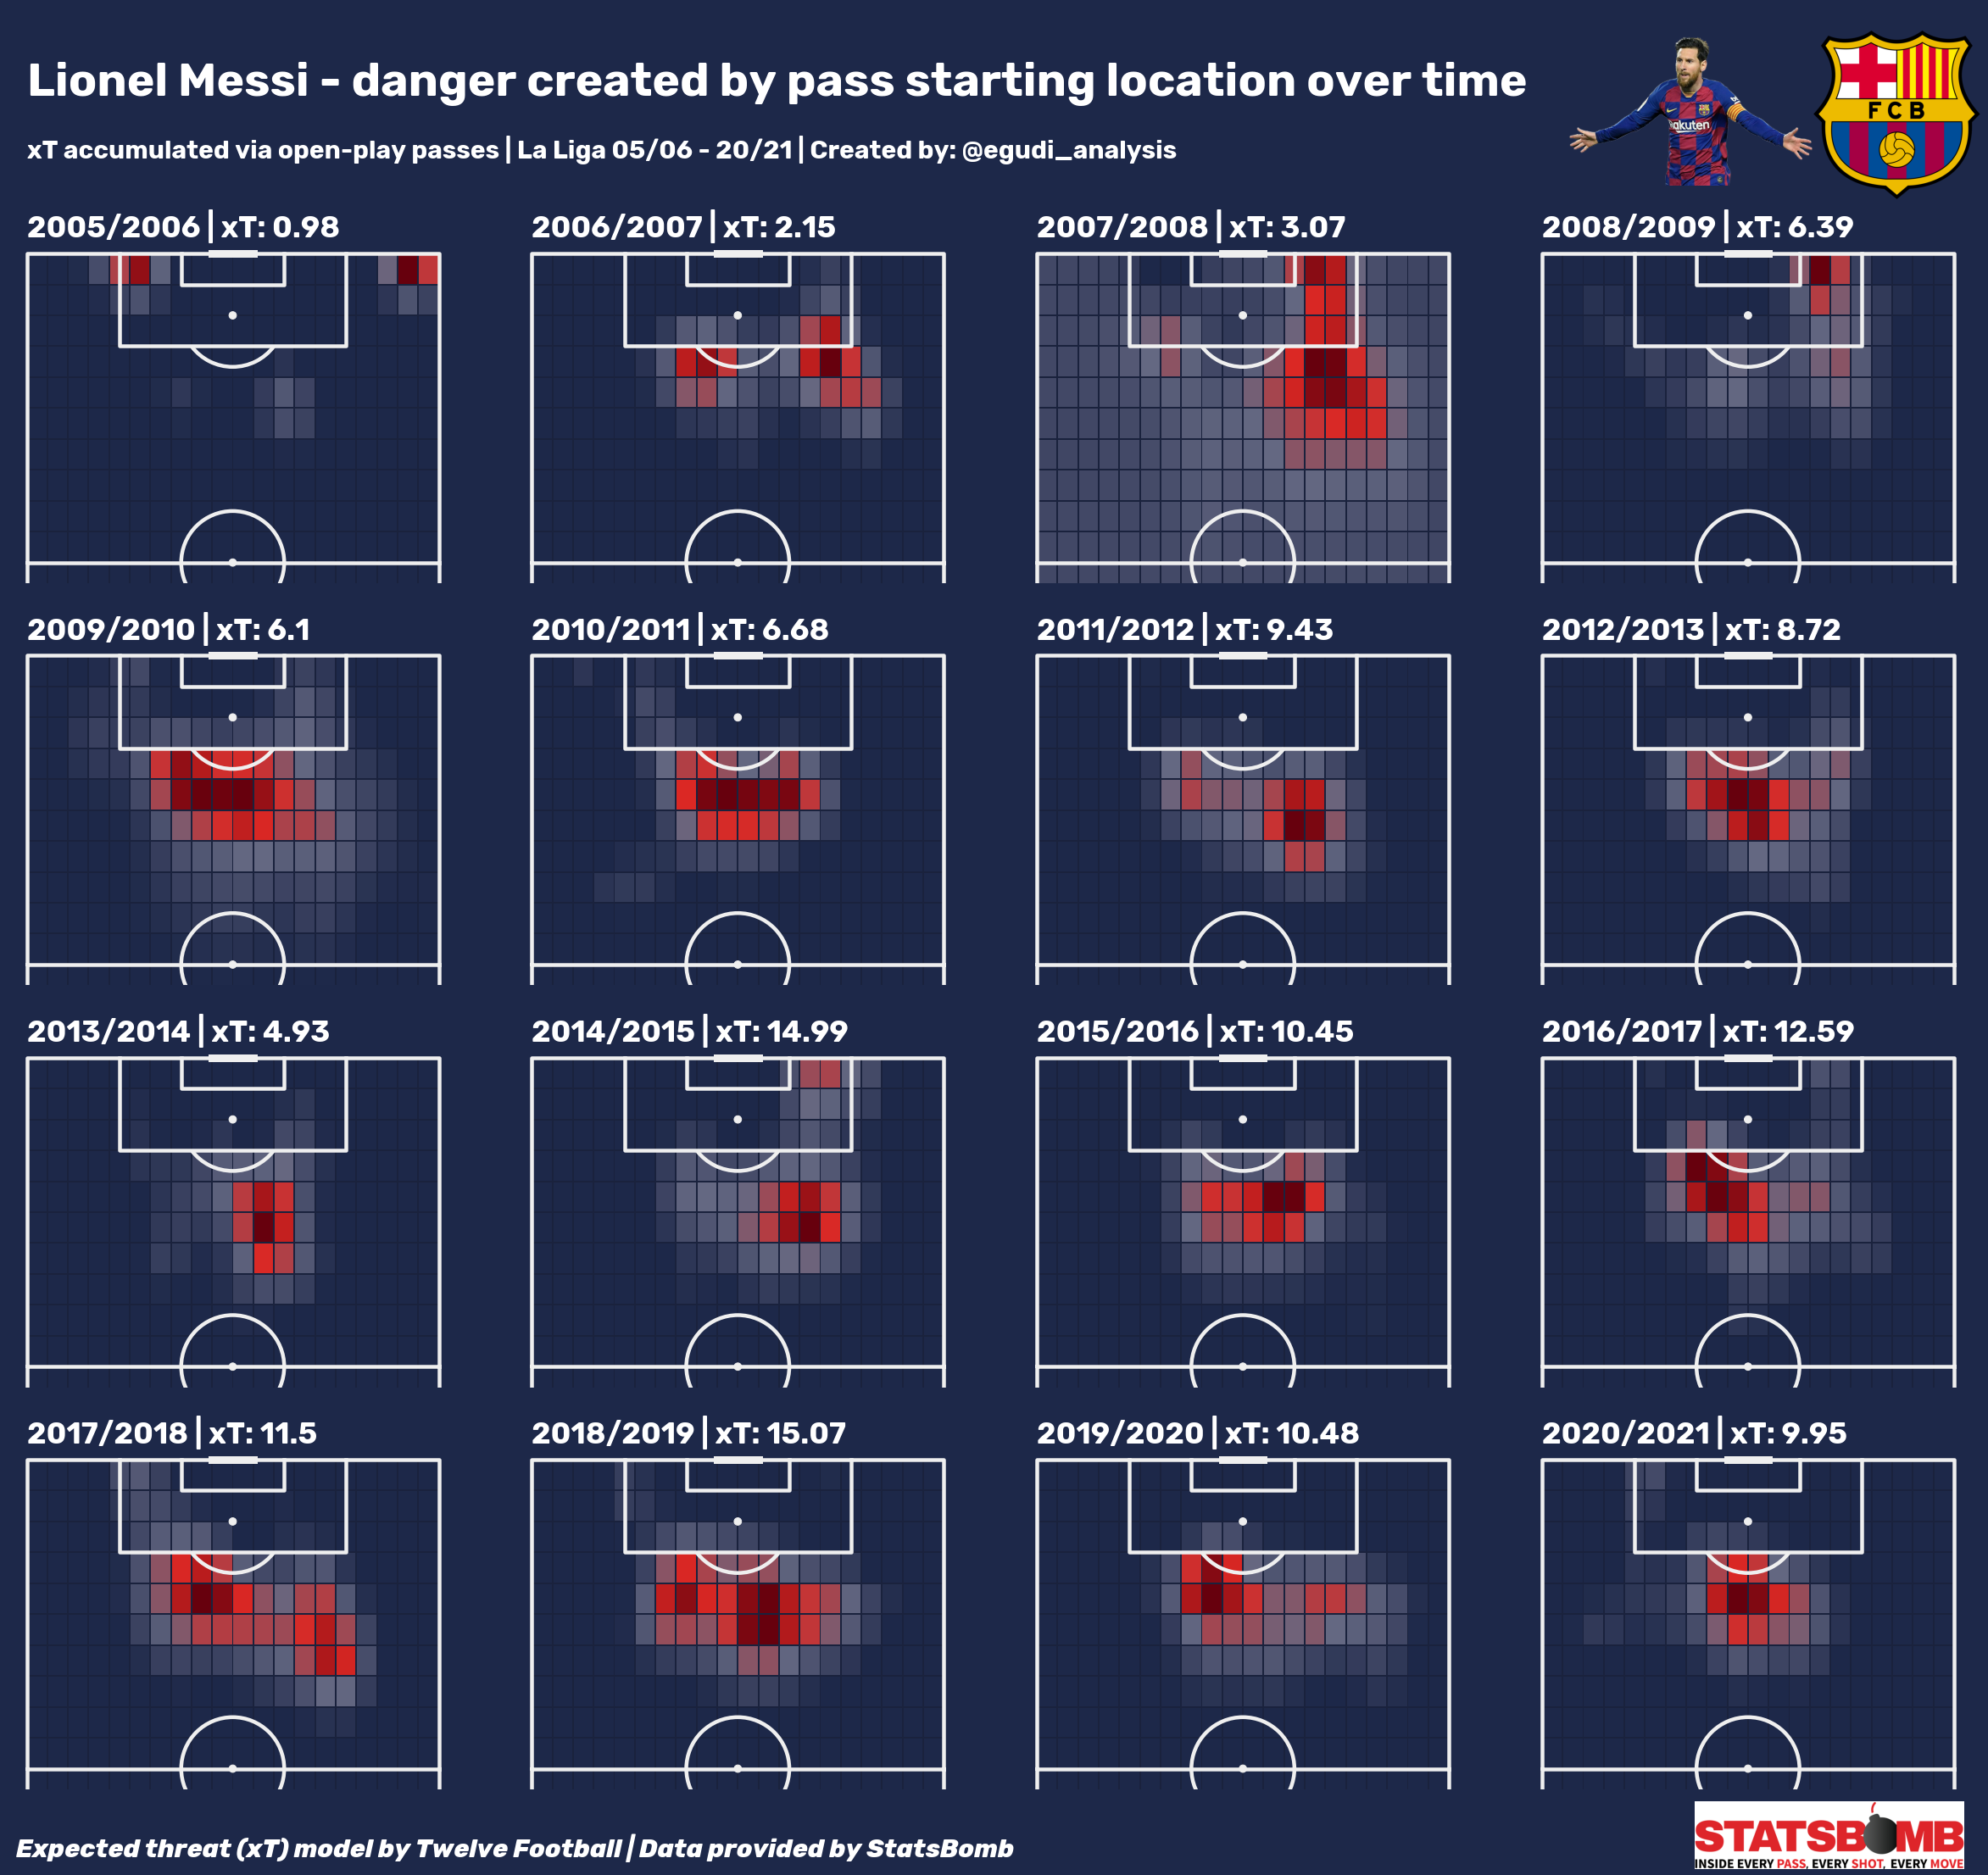

In [16]:
# These are the fonts and colors I like to use; feel free to change to your prefered fonts/colots
Rubik = FontManager('https://github.com/googlefonts/rubik/blob/main/fonts/ttf/Rubik-Bold.ttf?raw=true')
Rubik_italic = FontManager('https://github.com/googlefonts/rubik/blob/main/fonts/ttf/Rubik-ExtraBoldItalic.ttf?raw=true')
customcmap = LinearSegmentedColormap.from_list('custom cmap', ['#1d2849', '#1d2849', '#414765', '#646882', '#db2824', '#67000d'])

# use your twitter handle
twitter_handle = '@egudi_analysis'

# single column df with seasons which will be used to iterate within each pitch in the grid for labeling
seasons = xt_ssn.season
# identify how many seasons we have
# we will use this in the loop for only plotting pass heatmaps for as
# many seasons we have data for
num_seaons = len(seasons)

#set your mplsoccer pitch characteristics
pitch = VerticalPitch(pitch_type='statsbomb',
                      pitch_color='#1d2849', line_color='#efefef',half = True,
                      line_zorder=1, linewidth=4.5, spot_scale=0.006)
#create your grid of pitches
#nrows sets the number of rows, ncols sets the number of cols
#title height sets the portion of the fig height left for the title, grid height does the same for the grid of pitches
#space lets you determine how much height is between each individual pitch
fig, axs = pitch.grid(nrows=4, ncols=4, figheight=30,
                      endnote_height=0.0, endnote_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                     #those comments from the mplsoccer docs themselves, figured I'd just leave them in
                      axis=False,
                      title_height=0.05, grid_height=0.85, space=0.1)
#set the face color of the figure, I like having this as the same color as my pitches
fig.set_facecolor('#1d2849')

#set your title, subtitle, and credits
fig.text(0.035, 0.97, "Lionel Messi - danger created by pass starting location over time",fontsize=55, color="white",
            fontproperties=Rubik.prop)
fig.text(0.035, 0.936, f'xT accumulated via open-play passes | La Liga 05/06 - 20/21 | Created by: {twitter_handle}',
         color='white', fontsize=30, fontproperties=Rubik.prop)
fig.text(0.03, 0.008, 'Expected threat (xT) model by Twelve Football | Data provided by StatsBomb',
         color='white', fontsize=30, fontproperties=Rubik_italic.prop)

# cycle through the grid axes and plot the player  heatmaps
for idx, ax in enumerate(axs['pitch'].flat):
    if idx < num_seaons:
        season = seasons.iloc[idx]
        season_yr = passes[passes['season'] == season]
        
        # apply mplsoccer's "bin_statisic" method to sum the aggregate xT created from each bin, based on start location
        # I used 20 bins by 20 but feel free to adjust
        bin_statistic = pitch.bin_statistic(season_yr.x, season_yr.y, season_yr.xT, statistic='sum', bins=(20, 20))
        # apply scipy's built in gaussian filter method to the bin_statistic variable
        bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
        # apply mplsoccer's built in heatmap method to get color code each bin based on the amount of xT
        pcm1 = pitch.heatmap(bin_statistic, ax=ax, cmap=customcmap, edgecolors='#1a223d')
        
        # annotate xT generated per season
        annotation_string = (f'{season} | xT: {round(season_yr.xT.sum(),2)}')
        ax_text(0, 122, annotation_string, ha='left', va='bottom', fontsize=35,
                ax=ax, color='white', fontproperties=Rubik.prop)

# remove any pitches you dont need
for ax in axs['pitch'].flat[16:]:
    ax.remove()

# add logos
path = 'Logos/statsbomb-logo.jpg'
ax_team = fig.add_axes([.84,-.045,0.13,0.13])
ax_team.axis('off')
im = plt.imread(path)
ax_team.imshow(im);

path = 'Logos/messi.png'
ax_team = fig.add_axes([.77,.905,0.13,0.13])
ax_team.axis('off')
im = plt.imread(path)
ax_team.imshow(im);

path = 'Logos/barca.png'
ax_team = fig.add_axes([.89,.912,0.095,0.095])
ax_team.axis('off')
im = plt.imread(path)
ax_team.imshow(im);
        
#save your figure as a high quality image
plt.savefig("Output/Messi_xT_passes.png", dpi = 200, bbox_inches='tight')